In [3]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import numpy as np
from matplotlib import pyplot as plt
from gwpy.timeseries import TimeSeries
import bilby
from bilby.core.prior import Uniform

In [4]:
logger = bilby.core.utils.logger
outdir = "outdir"
# gravitational wave source
label = "GW150914"  

H1 = bilby.gw.detector.get_empty_interferometer("H1")
L1 = bilby.gw.detector.get_empty_interferometer("L1")

In [5]:
event_start_time = 1126259462.4    # event GPS time at which first GW discovered
post_event = 2                     # time after event
pre_event = 2                      # time before event
duration = pre_event + post_event  # total time range containing event
analysis_begin = event_start_time - pre_event  # GPS time at which to start analysis

In [6]:
H1_data = TimeSeries.fetch_open_data("H1", analysis_begin, 
                                     analysis_begin + duration,
                                     sample_rate=4096, cache=True)

L1_data = TimeSeries.fetch_open_data("L1", analysis_begin, 
                                     analysis_begin + duration,
                                     sample_rate=4096, cache=True)

H1.set_strain_data_from_gwpy_timeseries(H1_data)
L1.set_strain_data_from_gwpy_timeseries(L1_data)

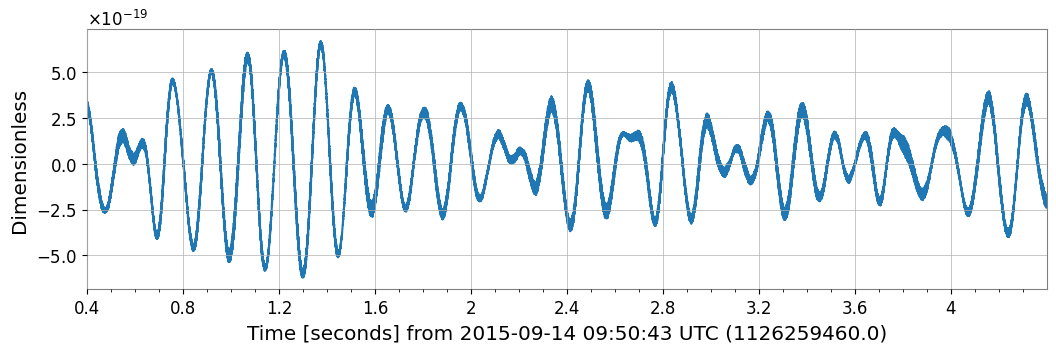

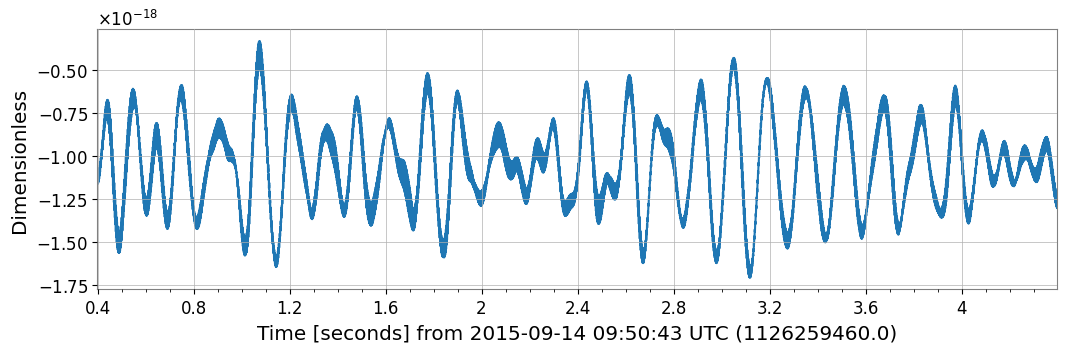

In [7]:
H1_data.plot()
plt.savefig("H1_data")
L1_data.plot()
plt.savefig("L1_data")

In [8]:
# duration typically multiplied by 32 for psd
psd_duration = duration * 32                
psd_begin = analysis_begin - psd_duration

# fetch data for psd
H1psd = TimeSeries.fetch_open_data(
    "H1", psd_begin, psd_begin + psd_duration,
    sample_rate=4096, cache=True)
L1psd = TimeSeries.fetch_open_data(
    "L1", psd_begin, psd_begin + psd_duration,
    sample_rate=4096, cache=True)

# set interferometers with psd data
psd_alpha = 2 * H1.strain_data.roll_off / duration
H1psd_data = H1psd.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
L1psd_data = L1psd.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
H1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1psd_data.frequencies.value, psd_array=H1psd_data.value)
L1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=L1psd_data.frequencies.value, psd_array=L1psd_data.value)

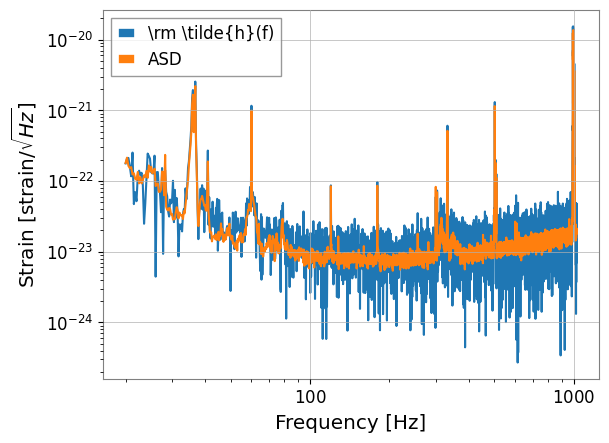

In [ ]:
H1.maximum_frequency = 1024
L1.maximum_frequency = 1024

plt.figure()
idxs = H1.strain_data.frequency_mask
a,b = list(H1.strain_data.frequency_array[idxs]),list(np.abs(H1.strain_data.frequency_domain_strain[idxs]))
c,d = list(H1.power_spectral_density.frequency_array[idxs]),list(H1.power_spectral_density.asd_array[idxs])
plt.plot(a,b, label = r'$\rm \tilde{h}(f)$')
plt.plot(c,d, label = 'ASD')
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Frequency [Hz]")
plt.ylabel("Strain [strain/$\sqrt{Hz}$]")
plt.legend(loc='upper left')
plt.savefig("strainvfreq")

In [10]:
H1_data.write("H1_data.gwf")
L1_data.write("L1_data.gwf")
H1psd.write("H1_psd.gwf")
L1psd.write("L1_psd.gwf")